In [1]:

import os
import cv2
import joblib
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn.functional as F
from torchvision import transforms

from classification.models import CytologyClassifier
from segmentation.features import extract_features
from segmentation.modelsUnet import UNet4Levels

def fuse_product(p1, p2, eps=1e-9):
    p = (p1+eps) * (p2+eps)
    return p / p.sum()

def fuse_sum(p1, p2, eps=1e-9):
    p = (p1 + eps) + (p2 + eps)
    return p / p.sum()
    
def fuse_weighted_avg(p1, p2, w=0.5):
    p = w * p1 + (1-w) * p2
    return p / (p.sum() + 1e-12)

def softmax(z): 
    z = z - z.max()
    e = np.exp(z); return e / e.sum()

def fuse_logit_avg(p1, p2, w=0.5, eps=1e-9):
    z1 = np.log(p1+eps); z2 = np.log(p2+eps)  # logity ~ log-prob
    z  = w*z1 + (1-w)*z2
    return softmax(z)


def R1(p): return 1.0 - np.exp(-((p-1.0)**2)/2.0)
def R2(p): return 1.0 - np.tanh(((p-1.0)**2)/2.0)

def fuse_rank_based(p1, p2):
    r_vgg = R1(p1) * R2(p1)
    r_xgb = R1(p2) * R2(p2)
    r = r_vgg + r_xgb
    return -r

def entropy(p):
    return -(p * np.log(p + 1e-9)).sum()

def fuse_dynamic(p1, p2):
    e1, e2 = entropy(p1), entropy(p2)
    w1 = 1 / (e1 + 1e-9)
    w2 = 1 / (e2 + 1e-9)
    p = (w1 * p1 + w2 * p2) / (w1 + w2)
    return p

def only_vgg(p1, p2):
    return p1

def only_xgb(p1, p2):
    return p2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_NAMES = ['HSIL', 'LSIL', 'NSIL']  

VGG_WEIGHTS = r'C:\Users\aleks\OneDrive\Documents\inzynierka\classification\classification_models\resnet18\16_0_0001_50_1110.pth'
ARCHITECTURE =  'resnet18' #or 'custom_cnn'

UNET_WEIGHTS = r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\unet4_cell_nucleus_4_50_1310.pth"
LIGHTGBM_MODEL_PATH = r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_RandomForest_new_unet.pkl"

# VGG
vgg_clf = CytologyClassifier(num_classes=len(CLASS_NAMES), architecture=ARCHITECTURE)
vgg_clf.load(VGG_WEIGHTS)
vgg_clf.model.eval().to(device)

# U-Net
unet = UNet4Levels(in_channels=3, out_channels=2)  # 2 kanały: [komórka, jądro]
unet.load_state_dict(torch.load(UNET_WEIGHTS, map_location='cpu'))
unet.eval().to(device)

# LightGBM + enkoder + scaler
lightgbm_model = joblib.load(LIGHTGBM_MODEL_PATH)['model']
label_encoder = joblib.load(LIGHTGBM_MODEL_PATH)['label_encoder']


def preprocess_image_for_vgg(img_pil: Image.Image) -> torch.Tensor:
    tfm = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return tfm(img_pil)

def preprocess_image_for_unet(img_pil: Image.Image, size: int = 256) -> torch.Tensor:
    tfm = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),  # [0,1]
    ])
    return tfm(img_pil)

@torch.inference_mode()
def predict_vgg_probs(model_or_wrapper, image_path: str) -> np.ndarray:
    img = Image.open(image_path).convert("RGB")
    x = preprocess_image_for_vgg(img).unsqueeze(0).to(device)

    net = getattr(model_or_wrapper, "model", model_or_wrapper)
    net.eval()
    logits = net(x)                   

    probs = F.softmax(logits, dim=1).squeeze(0).detach().cpu().numpy()
    return probs


from segmentation.modelsUnet import predict_masks 

def select_best_nucleus(mask: np.ndarray, image_shape=None) -> np.ndarray:
    # mask: (H,W) w [0,1] (jądro)
    m = (mask * 255).astype(np.uint8)
    contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.zeros_like(m)

    if image_shape is None:
        h, w = m.shape
    else:
        h, w = image_shape
    center = np.array([w // 2, h // 2])

    best_score, best_contour = -np.inf, None
    for cnt in contours:
        if len(cnt) < 5:
            continue
        ellipse = cv2.fitEllipse(cnt)
        (x, y), (MA, ma), angle = ellipse
        if MA == 0 or ma == 0:
            continue
        owalnosc = min(MA, ma) / max(MA, ma)
        nucleus_center = np.array([x, y])
        dist_to_center = np.linalg.norm(nucleus_center - center)
        score = owalnosc / (dist_to_center + 1e-5)
        if score > best_score:
            best_score, best_contour = score, cnt

    out = np.zeros_like(m, dtype=np.uint8)
    if best_contour is not None:
        cv2.drawContours(out, [best_contour], -1, 255, thickness=-1)
    return out  # (H,W) 0/255

FEATURE_NAMES = ['N', 'C', 'NCr', 'Np', 'Cp', 'NCp', 'MinA', 'MinAr', 'MaxA', 'MaxAr',
                 'Nar', 'Car', 'NCar', 'NExt', 'CExt', 'NCExt', 'NSol', 'CSol', 'NCs',
                 'EqN', 'EqC', 'NCEq', 'OrN', 'OrC', 'NCOr']

def predict_gbm_probs(model, label_encoder, input_features: dict) -> np.ndarray:
    try:
        X_new = pd.DataFrame([[input_features[f] for f in FEATURE_NAMES]], columns=FEATURE_NAMES)
    except KeyError as e:
        raise ValueError(f"Brakuje cechy w słowniku: {e}")

    proba = model.predict_proba(X_new)  # <-- tu nie używaj model["model"]
    classes_model = list(label_encoder.classes_)   
    probs_aligned = np.zeros(len(CLASS_NAMES), dtype=np.float32)
    for i, cname in enumerate(CLASS_NAMES):
        if cname in classes_model:
            probs_aligned[i] = proba[0, classes_model.index(cname)]
        else:
            probs_aligned[i] = 0.0

    s = probs_aligned.sum()
    if s > 0:
        probs_aligned = probs_aligned / s
    return probs_aligned


def run_pipeline(image_path: str, extract_features_fn, fuse_func) -> dict:
    # --- 1) VGG ---
    probs_vgg = predict_vgg_probs(vgg_clf, image_path)  # (K,)

    # --- 2) U-Net + cechy + XGBoost ---
    img_pil = Image.open(image_path).convert("RGB")
    image_tensor = preprocess_image_for_unet(Image.open(image_path).convert("RGB")).unsqueeze(0).to(device)
    masks = predict_masks(unet, image_tensor, device=device)
    mask_cell = (masks[0] > 0.5).astype(np.uint8) * 255
    mask_nuc_soft = masks[1]
    best_nucleus = select_best_nucleus(mask_nuc_soft, image_shape=np.array(img_pil).shape[:2])


    feat_dict = extract_features_fn(best_nucleus, mask_cell)
    probs_gbm = predict_gbm_probs(lightgbm_model, label_encoder, feat_dict)  # (K,)


    fused = fuse_func(probs_vgg, probs_gbm)
    pred_idx = int(np.argmax(fused))
    pred_label = CLASS_NAMES[pred_idx]
    

    return {
        "vgg_probs": np.round(probs_vgg, 3),
        "gbm_probs": np.round(probs_gbm, 3),
        "fused_scores": np.round(fused, 3),
        "pred_idx": pred_idx,
        "pred_label": pred_label,
        "best_nucleus_mask": best_nucleus,
        "cell_mask": mask_cell,
        "features": feat_dict
    }


c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, RocCurveDisplay
)

def metrics_and_plots(fuse_func):
    # --- zbieranie wyników ---
    y_true, y_pred, y_scores = [], [], []  # scores = wektory fused_probs

    test_root = r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\test"
    valid_ext = (".bmp", ".jpg", ".jpeg", ".png")

    for class_name in os.listdir(test_root):
        class_dir = os.path.join(test_root, class_name)
        if not os.path.isdir(class_dir):
            continue
        for fname in os.listdir(class_dir):
            if not fname.lower().endswith(valid_ext):
                continue

            image_path = os.path.join(class_dir, fname)
            result = run_pipeline(image_path, extract_features, fuse_func)

            y_true.append(class_name)                 # ground truth = nazwa folderu
            y_pred.append(result["pred_label"])       # predykcja
            y_scores.append(result["fused_scores"])   # wektor prob

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_scores = np.array(y_scores)   # shape = (N, K)

    CLASS_NAMES = ['HSIL', 'LSIL', 'NSIL']

    # --- metryki ---
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    # --- confusion matrix (znormalizowana) ---
    cm_norm = confusion_matrix(y_true, y_pred, labels=CLASS_NAMES, normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=CLASS_NAMES)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix (Fusion, normalized) - {fuse_func.__name__}")
    plt.show()

    # --- ROC i AUC ---
    plt.figure(figsize=(8, 6))

    for i, cls in enumerate(CLASS_NAMES):
        y_true_bin = (y_true == cls).astype(int)  # one-vs-rest
        fpr, tpr, _ = roc_curve(y_true_bin, y_scores[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{cls} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], "k--", lw=2)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC curves for all classes - {fuse_func.__name__}")
    plt.legend(loc="lower right")
    plt.show()


Accuracy : 0.9515
Precision: 0.9479
Recall   : 0.9583
F1-score : 0.9495


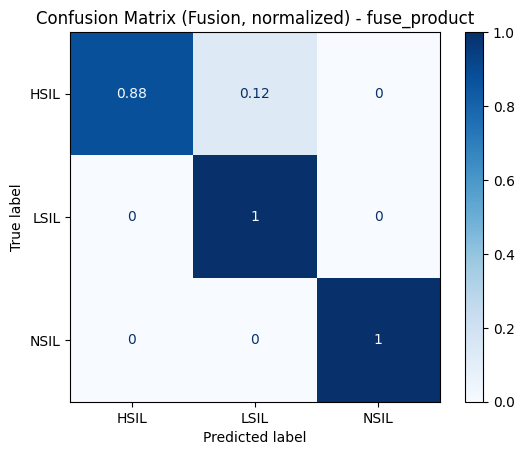

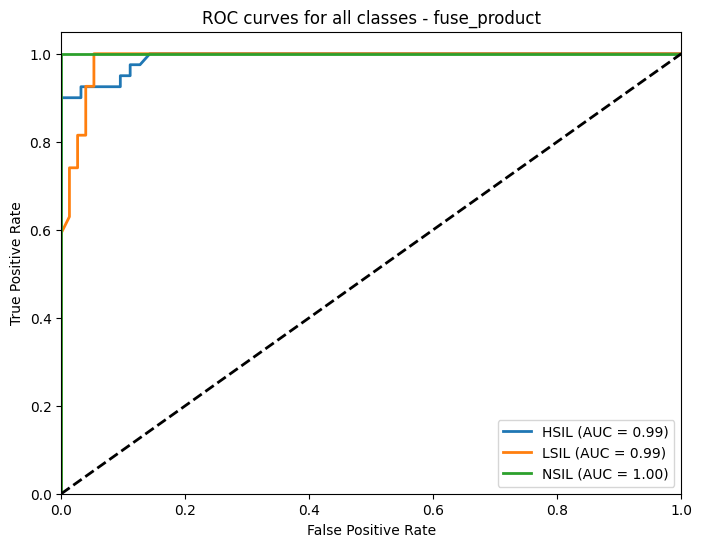

In [4]:
metrics_and_plots(fuse_product)

Accuracy : 0.9515
Precision: 0.9479
Recall   : 0.9583
F1-score : 0.9495


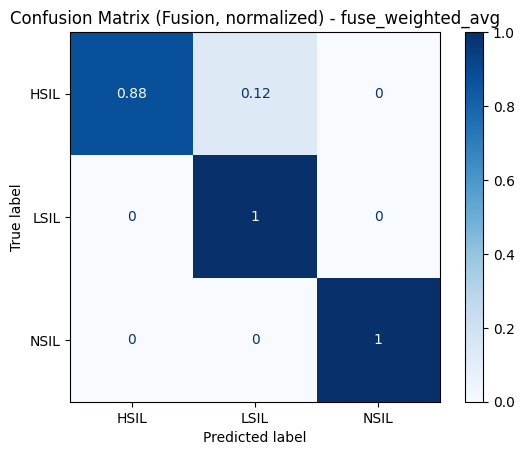

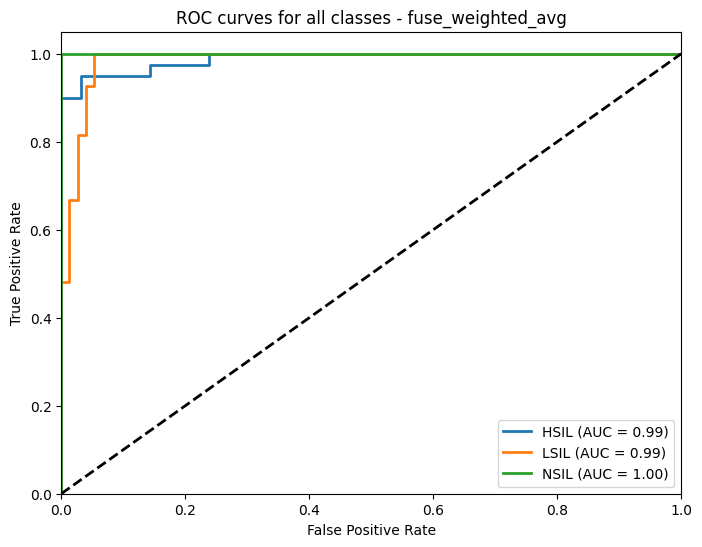

In [5]:
metrics_and_plots(fuse_weighted_avg)

Accuracy : 0.9515
Precision: 0.9479
Recall   : 0.9583
F1-score : 0.9495


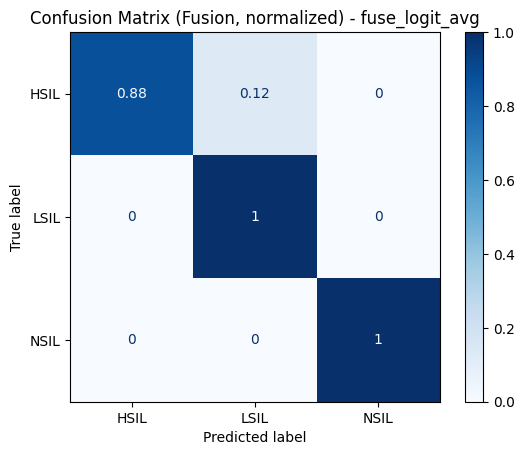

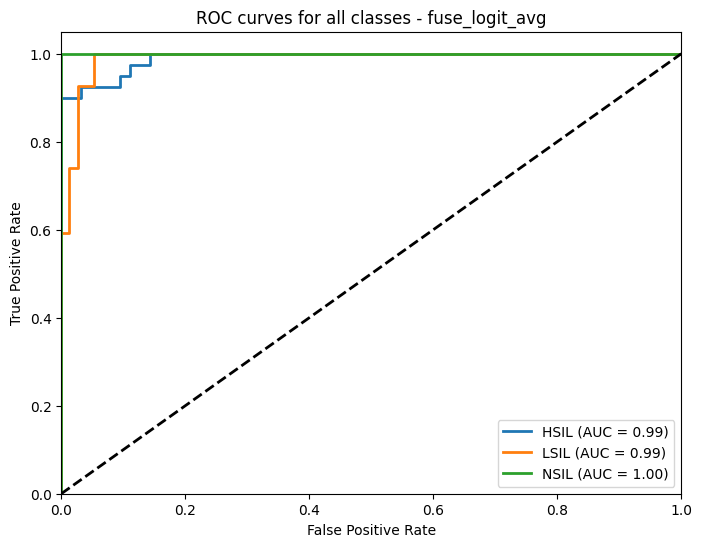

In [6]:
metrics_and_plots(fuse_logit_avg)

Accuracy : 0.9515
Precision: 0.9479
Recall   : 0.9583
F1-score : 0.9495


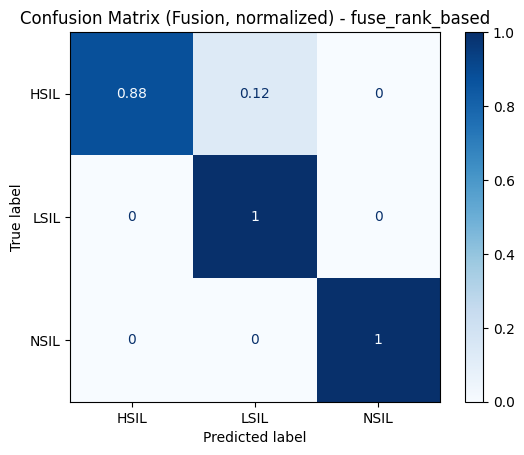

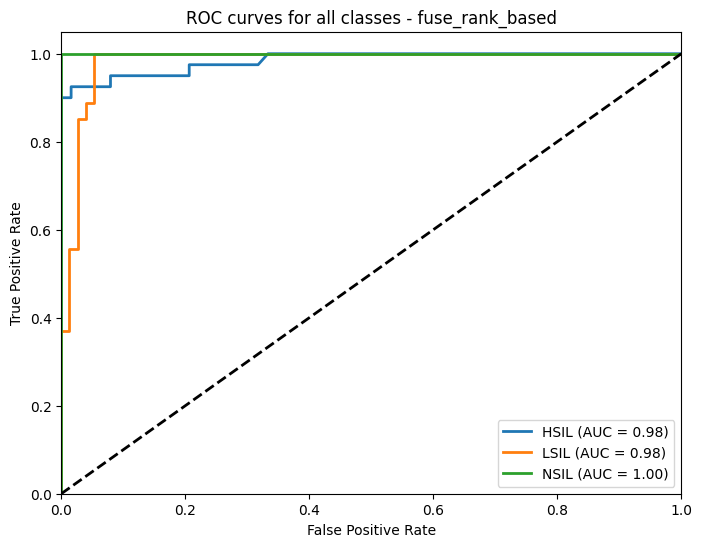

In [7]:
metrics_and_plots(fuse_rank_based)

In [8]:
import os
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, precision_score, recall_score, f1_score, classification_report
from segmentation.modelsUnet import preprocess_image

y_true = []
y_pred = []

folder = r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\TEST'

model = UNet4Levels(in_channels=3, out_channels=2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\unet4_cell_nucleus_4_50_1310.pth"))
model.to(device)



for subfolder in os.listdir(folder):
    true_class = os.path.basename(subfolder)
    for filename in os.listdir(os.path.join(folder, subfolder)):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
            image_path = os.path.join(folder, subfolder, filename)
            predicted_class = run_pipeline(image_path, extract_features, fuse_rank_based)["pred_label"]
            y_true.append(true_class)
            y_pred.append(predicted_class)


acc = accuracy_score(y_true, y_pred)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
y_true, y_pred, labels=label_encoder.classes_, average="macro", zero_division=0
    )
prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=label_encoder.classes_, average="weighted", zero_division=0
    )

print("\n=== METRYKI (global) ===")
print(f"Accuracy:            {acc:.4f}")
print(f"Precision (macro):   {prec_macro:.4f}")
print(f"Recall    (macro):   {rec_macro:.4f}")
print(f"F1        (macro):   {f1_macro:.4f}")
print(f"Precision (weighted):{prec_weighted:.4f}")
print(f"Recall    (weighted):{rec_weighted:.4f}")
print(f"F1        (weighted):{f1_weighted:.4f}")

print("\n=== RAPORT (per klasa) ===")
print(classification_report(y_true, y_pred, labels=label_encoder.classes_, digits=4))

cm = confusion_matrix(y_true, y_pred, labels=label_encoder.classes_, normalize='true')
cm_df = pd.DataFrame(
        cm,
        index=[f"true_{l}" for l in label_encoder.classes_],
        columns=[f"pred_{l}" for l in label_encoder.classes_],
    )
print("\n=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===")
print(cm_df)



fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.set_title("Confusion Matrix (HSIL/LSIL/NSIL, normalized)")
tick_marks = np.arange(len(label_encoder.classes_))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(label_encoder.classes_)
ax.set_yticklabels(label_encoder.classes_)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", color="black")

ax.set_ylabel("True class")
ax.set_xlabel("Predicted class")
fig.tight_layout()
plt.close()


=== METRYKI (global) ===
Accuracy:            0.9310
Precision (macro):   0.9360
Recall    (macro):   0.9333
F1        (macro):   0.9332
Precision (weighted):0.9338
Recall    (weighted):0.9310
F1        (weighted):0.9309

=== RAPORT (per klasa) ===
              precision    recall  f1-score   support

        HSIL     0.8636    0.9500    0.9048        20
        LSIL     0.9444    0.8500    0.8947        20
        NSIL     1.0000    1.0000    1.0000        18

    accuracy                         0.9310        58
   macro avg     0.9360    0.9333    0.9332        58
weighted avg     0.9338    0.9310    0.9309        58


=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===
           pred_HSIL  pred_LSIL  pred_NSIL
true_HSIL       0.95       0.05        0.0
true_LSIL       0.15       0.85        0.0
true_NSIL       0.00       0.00        1.0


Accuracy : 0.9515
Precision: 0.9479
Recall   : 0.9583
F1-score : 0.9495


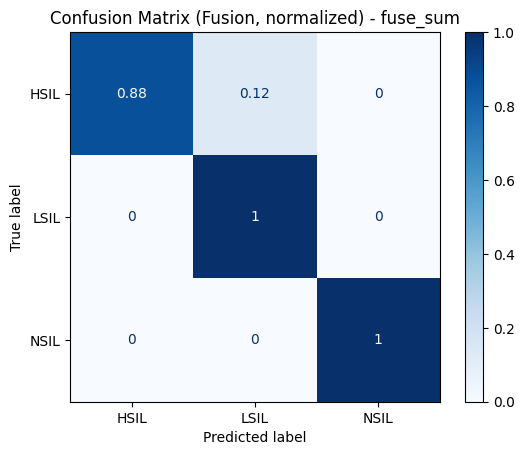

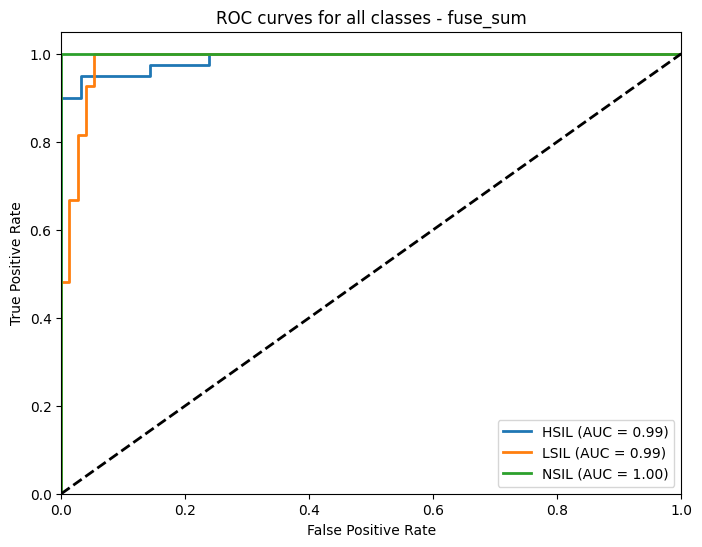

In [9]:
metrics_and_plots(fuse_sum)

Accuracy : 0.9515
Precision: 0.9479
Recall   : 0.9583
F1-score : 0.9495


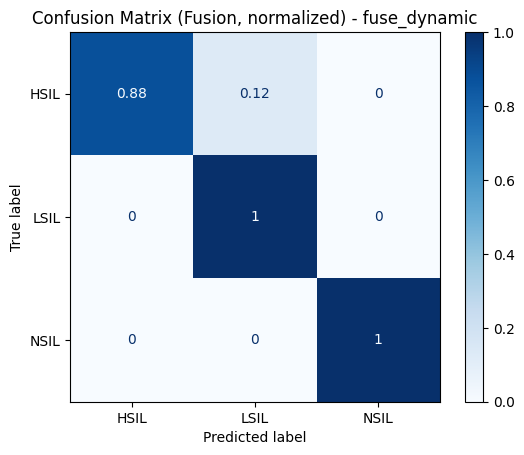

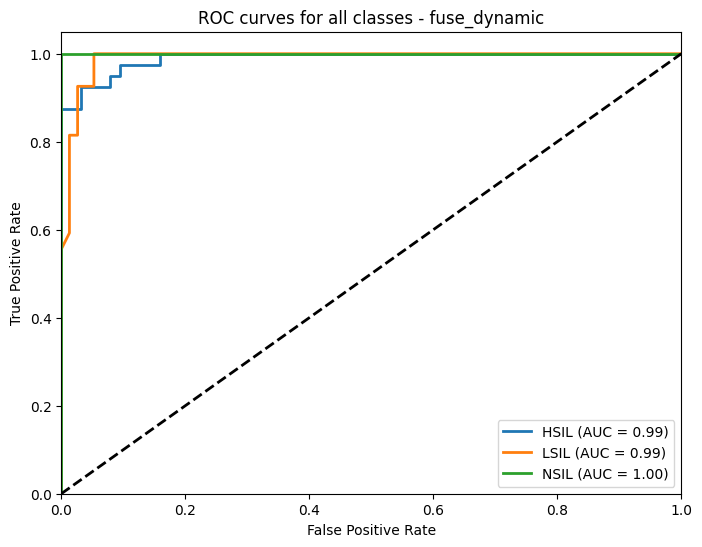

In [10]:
metrics_and_plots(fuse_dynamic)

In [4]:
def get_probs_vgg(folder_path):
    vgg_probs_hsil = []
    vgg_probs_lsil = []
    vgg_probs_nsil = []

    for subfolder in os.listdir(folder_path):
        for filename in os.listdir(os.path.join(folder_path, subfolder)):
            if not filename.lower().endswith(('.bmp', '.jpg', '.jpeg', '.png')):
                continue
            image_path = os.path.join(folder_path, subfolder, filename)
            probs = predict_vgg_probs(vgg_clf, image_path)
            vgg_probs_hsil.append(probs[0])
            vgg_probs_lsil.append(probs[1])
            vgg_probs_nsil.append(probs[2])
    return vgg_probs_hsil, vgg_probs_lsil, vgg_probs_nsil


In [5]:
from segmentation.modelsUnet import preprocess_image
def get_probs_lg(folder_path):
    lg_probs_hsil = []
    lg_probs_lsil = []
    lg_probs_nsil = []

    for subfolder in os.listdir(folder_path):
        for filename in os.listdir(os.path.join(folder_path, subfolder)):
            if not filename.lower().endswith(('.bmp', '.jpg', '.jpeg', '.png')):
                continue
            image_path = os.path.join(folder_path, subfolder, filename)
            pil_image, input_tensor = preprocess_image(image_path)
            predicted_masks = predict_masks(unet, input_tensor, device, threshold_nuclei=0.3, threshold_cell=0.7)
            mask_cell = (predicted_masks[0] > 0.5).astype(np.uint8) * 255
            mask_nuc_soft = predicted_masks[1]
            best_nucleus = select_best_nucleus(mask_nuc_soft, image_shape=np.array(pil_image).shape[:2])

            feat_dict = extract_features(best_nucleus, mask_cell)
            probs = predict_gbm_probs(lightgbm_model, label_encoder, feat_dict)

            lg_probs_hsil.append(probs[0])
            lg_probs_lsil.append(probs[1])
            lg_probs_nsil.append(probs[2])
    return lg_probs_hsil, lg_probs_lsil, lg_probs_nsil


In [6]:
lg_probs_hsil, lg_probs_lsil, lg_probs_nsil = get_probs_lg(r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\train")
vgg_probs_hsil, vgg_probs_lsil, vgg_probs_nsil = get_probs_vgg(r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\train")
df1 = pd.read_csv(r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\features_train_new_unet"".csv")
df1['lg_hsil'] = lg_probs_hsil   
df1['lg_lsil'] = lg_probs_lsil
df1['lg_nsil'] = lg_probs_nsil
df1['vgg_hsil'] = vgg_probs_hsil   
df1['vgg_lsil'] = vgg_probs_lsil
df1['vgg_nsil'] = vgg_probs_nsil

lg_probs_hsil, lg_probs_lsil, lg_probs_nsil = get_probs_lg(r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\val")
vgg_probs_hsil, vgg_probs_lsil, vgg_probs_nsil = get_probs_vgg(r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\val")
df2 = pd.read_csv(r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\features_val_new_unet"".csv")
df2['lg_hsil'] = lg_probs_hsil   
df2['lg_lsil'] = lg_probs_lsil
df2['lg_nsil'] = lg_probs_nsil
df2['vgg_hsil'] = vgg_probs_hsil   
df2['vgg_lsil'] = vgg_probs_lsil
df2['vgg_nsil'] = vgg_probs_nsil

df_train = pd.concat([df1, df2], ignore_index=True)

In [14]:
df_train.head()

,N,C,NCr,Np,Cp,NCp,MinA,MinAr,MaxA,MaxAr,...,OrN,OrC,NCOr,class,lg_hsil,lg_lsil,lg_nsil,vgg_hsil,vgg_lsil,vgg_nsil
0,6351,17492,0.363080,410.391916,1065.997036,0.384984,61.330521,0.600752,145.526630,0.521758,...,-0.239361,0.040196,-5.954837,HSIL,0.979167,0.020833,0.0,0.998725,0.000709,0.000566
1,5550,12251,0.453024,348.232536,492.114785,0.707625,59.385822,0.715382,121.918005,0.589975,...,14.904083,35.629260,0.418310,HSIL,0.995816,0.004184,0.0,0.999190,0.000751,0.000059
2,978,3125,0.312960,162.568541,287.338093,0.565774,17.233763,0.521670,68.658576,0.553968,...,-0.439244,-0.458938,0.957087,HSIL,0.958673,0.041327,0.0,0.998481,0.000600,0.000919
3,864,2465,0.350507,152.752307,236.007140,0.647236,16.963255,0.517228,65.192024,0.663122,...,-2.856079,-7.153759,0.399242,HSIL,0.950000,0.050000,0.0,0.996767,0.002334,0.000899
4,13099,44180,0.296492,697.511754,960.950353,0.725856,108.330750,0.582786,197.294197,0.570527,...,-2.943298,4.890625,-0.601824,HSIL,0.944347,0.055653,0.0,0.999851,0.000092,0.000057


In [7]:
vgg_probs_hsil, vgg_probs_lsil, vgg_probs_nsil = get_probs_vgg(r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\test")
lg_probs_hsil, lg_probs_lsil, lg_probs_nsil = get_probs_lg(r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\test")
df_test = pd.read_csv(r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\features_test_new_unet"".csv")
df_test['lg_hsil'] = lg_probs_hsil   
df_test['lg_lsil'] = lg_probs_lsil
df_test['lg_nsil'] = lg_probs_nsil
df_test['vgg_hsil'] = vgg_probs_hsil   
df_test['vgg_lsil'] = vgg_probs_lsil
df_test['vgg_nsil'] = vgg_probs_nsil
df_test.head()

,N,C,NCr,Np,Cp,NCp,MinA,MinAr,MaxA,MaxAr,...,OrN,OrC,NCOr,class,lg_hsil,lg_lsil,lg_nsil,vgg_hsil,vgg_lsil,vgg_nsil
0,21857,53377,0.409483,658.825463,1317.477264,0.500066,163.503189,0.664647,195.494245,0.628024,...,0.377274,0.889686,0.424052,HSIL,0.964073,0.035927,0.00,0.999997,2.060673e-07,0.000002
1,20814,50816,0.409595,671.997036,2457.013404,0.273502,150.598938,0.604815,189.770915,0.551024,...,7.777347,5.573127,1.395509,HSIL,0.999073,0.000927,0.00,0.999989,4.000100e-07,0.000010
2,505,1017,0.496559,86.526911,126.225395,0.685495,19.546383,0.691567,30.149627,0.634483,...,0.172932,0.243752,0.709462,HSIL,0.922857,0.077143,0.00,0.984050,2.556558e-04,0.015694
3,275,886,0.310384,60.870057,114.426407,0.531958,18.000000,0.620690,22.203603,0.500000,...,28.255791,-1.750947,-16.137436,HSIL,0.838673,0.141327,0.02,0.983741,1.128357e-03,0.015131
4,19309,49388,0.390965,578.499561,1467.016367,0.394337,153.282349,0.649501,175.000000,0.596842,...,-0.910993,1.219909,-0.746772,HSIL,0.998239,0.001761,0.00,0.999896,6.591124e-05,0.000039


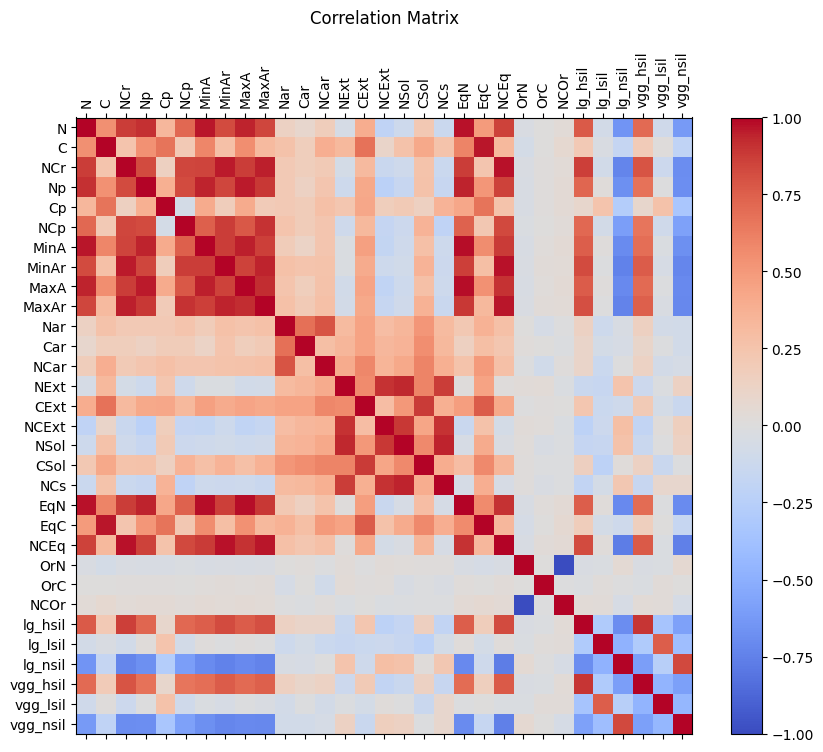

In [16]:
corr = df_train.drop(columns=['class']).corr()

fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(corr, cmap="coolwarm")  # możesz zmienić cmap
fig.colorbar(cax)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

plt.title("Correlation Matrix", pad=20)
plt.show()

In [8]:
X_train, y_train = df_train.drop(columns=["class"]), df_train["class"]
X_test,  y_test  = df_test.drop(columns=["class"]),  df_test["class"]

In [18]:
from lightgbm import LGBMClassifier
from sklearn.discriminant_analysis import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.neural_network import MLPClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_svm = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("clf", SVC(probability=True, random_state=42))
])

pipe_mlp = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("clf", MLPClassifier(solver="adam", random_state=42, max_iter=1000))
])

pipe_rf = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", RandomForestClassifier(random_state=42))
])

pipe_xgb = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", XGBClassifier(
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    ))
])

pipe_lgbm = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", LGBMClassifier(random_state=42))
])

pipelines = {
    "SVM": pipe_svm,
    "NeuralNet": pipe_mlp,
    "RandomForest": pipe_rf,
    "XGBoost": pipe_xgb,
    "LightGBM": pipe_lgbm
}

param_grids = {
    "SVM": {
        "clf__C": [0.01, 0.1, 1, 10, 100],
        "clf__gamma": ["scale", 1, 0.1, 0.01, 0.001],
        "clf__kernel": ["rbf", "poly", "sigmoid"]
    },
    "NeuralNet": {
        "clf__hidden_layer_sizes": [(32, 16), (64, 32), (128, 64), (128, 64, 32)],
        "clf__activation": ["relu", "tanh", "logistic"],
        "clf__batch_size": [32, 64, 16],
        "clf__alpha": [1e-4, 1e-3, 1e-2],
        "clf__learning_rate_init": [1e-3, 1e-2], 
        "clf__n_iter_no_change": [10, 20],
        "clf__max_iter": [300, 600, 1000],
    },
    "RandomForest": {
        "clf__n_estimators": [100, 200, 500],
        "clf__max_depth": [None, 10, 20, 30],
        "clf__min_samples_split": [2, 5, 10],
        "clf__min_samples_leaf": [1, 2, 4]
    },
    "XGBoost": {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [3, 5, 7],
        "clf__learning_rate": [0.01, 0.1, 0.2],
        "clf__subsample": [0.8, 1.0],
        "clf__colsample_bytree": [0.8, 1.0]
        # Alternatywa dla SMOTE: clf__scale_pos_weight (gdy duża nierównowaga)
    },
    "LightGBM": {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [-1, 10, 20],
        "clf__learning_rate": [0.01, 0.1, 0.2],
        "clf__num_leaves": [31, 50, 100],
        "clf__subsample": [0.8, 1.0],
        "clf__colsample_bytree": [0.8, 1.0],
        "clf__min_child_samples": [10, 20, 50],
    }
}

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y_train) 

y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

In [20]:
results = []
for name, pipe in pipelines.items():
    print(f"\n=== GridSearch dla {name} ===")
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=2,
        refit=True  
    )
    grid.fit(X_train, y_train_enc)

    best_model = grid.best_estimator_
    best_params = grid.best_params_

    y_test_pred_enc = best_model.predict(X_test)
    y_test_pred = le.inverse_transform(y_test_pred_enc)

    results.append({
        "Model": name,
        "Split": "Test",
        "Best_Params": best_params,
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_test, y_test_pred, average="macro", zero_division=0),
        "F1": f1_score(y_test, y_test_pred, average="macro", zero_division=0)
    })

    joblib.dump({"model": best_model, "label_encoder": le}, f"segmentation/models_paths/joined/model_probs_1410_{name}2.pkl")


results = pd.DataFrame(results).sort_values("F1", ascending=False)
print("\n=== Results ===")
print(results)



=== GridSearch dla SVM ===
Fitting 5 folds for each of 75 candidates, totalling 375 fits

=== GridSearch dla NeuralNet ===
Fitting 5 folds for each of 1296 candidates, totalling 6480 fits

=== GridSearch dla RandomForest ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits

=== GridSearch dla XGBoost ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits


c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:19:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== GridSearch dla LightGBM ===
Fitting 5 folds for each of 972 candidates, totalling 4860 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000629 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5961
[LightGBM] [Info] Number of data points in the train set: 624, number of used features: 31
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

===

In [21]:
results

,Model,Split,Best_Params,Accuracy,Precision,Recall,F1
0,SVM,Test,"{'clf__C': 100, 'clf__gamma': 0.001, 'clf__ker...",0.951456,0.947917,0.958333,0.949529
1,NeuralNet,Test,"{'clf__activation': 'relu', 'clf__alpha': 0.01...",0.941748,0.938657,0.949074,0.940741
2,RandomForest,Test,"{'clf__max_depth': None, 'clf__min_samples_lea...",0.941748,0.939394,0.950000,0.939640
3,XGBoost,Test,"{'clf__colsample_bytree': 0.8, 'clf__learning_...",0.941748,0.939394,0.950000,0.939640
4,LightGBM,Test,"{'clf__colsample_bytree': 0.8, 'clf__learning_...",0.941748,0.939394,0.950000,0.939640


In [27]:
results.to_csv(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\joined\results_fusion_1410.csv", index=False)

In [11]:
from sklearn.calibration import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_multiclass_roc(model, label_encoder, classes, X_test, y_test, title="ROC Curve"):
    y_proba = model.predict_proba(X_test)  
    y_true_enc = label_encoder.transform(y_test)               
    plt.figure(figsize=(8, 6))
    n_classes = len(classes)

    y_true_bin = label_binarize(y_true_enc, classes=np.arange(n_classes))

    macro_auc = roc_auc_score(y_true_bin, y_proba, multi_class="ovr", average="macro")
    print(f"Macro AUC (OvR): {macro_auc:.4f}")

    plt.figure(figsize=(8, 6))
    for i, cls in enumerate(classes):
        if y_true_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        cls_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cls} (AUC = {cls_auc:.2f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, classes, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
    plt.title(title)
    plt.show()


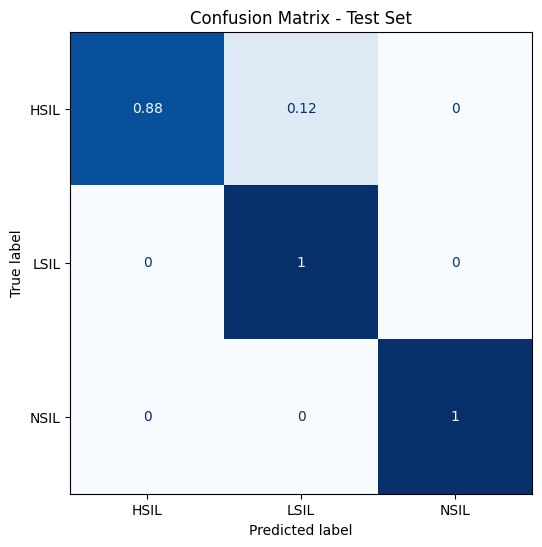

In [12]:
model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\joined\model_probs_1410_SVM2.pkl")
y_test_pred = model_class["model"].predict(X_test)
y_test_pred = le.inverse_transform(y_test_pred)
label_encoder = model_class["label_encoder"]
classes = list(label_encoder.classes_)
plot_confusion_matrix(y_test, y_test_pred, classes, title="Confusion Matrix - Test Set")

In [13]:
def print_classification_metrics(y_true, y_pred, classes, title="Classification Metrics"):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
    acc = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, labels=classes, average="macro", zero_division=0)
    rec_macro = recall_score(y_true, y_pred, labels=classes, average="macro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, labels=classes, average="macro", zero_division=0)
    print(f"\n=== {title} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision (macro): {prec_macro:.4f}")
    print(f"Recall (macro):    {rec_macro:.4f}")
    print(f"F1 (macro):        {f1_macro:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, labels=classes, digits=4))

In [14]:
print_classification_metrics(y_test, y_test_pred, classes, title="Test Set Metrics")


=== Test Set Metrics ===
Accuracy:  0.9515
Precision (macro): 0.9479
Recall (macro):    0.9583
F1 (macro):        0.9495

Classification report:
              precision    recall  f1-score   support

        HSIL     1.0000    0.8750    0.9333        40
        LSIL     0.8438    1.0000    0.9153        27
        NSIL     1.0000    1.0000    1.0000        36

    accuracy                         0.9515       103
   macro avg     0.9479    0.9583    0.9495       103
weighted avg     0.9590    0.9515    0.9519       103



In [26]:
model_class['model'].named_steps["clf"]

SVC(C=100, gamma=0.001, probability=True, random_state=42)

In [28]:
# import shap

# train_shap_values = shap.TreeExplainer(model_class["model"].named_steps["clf"]).shap_values(df_train.drop('class', axis=1))
# test_shap_values = shap.TreeExplainer(model_class["model"].named_steps["clf"]).shap_values(X_test)

# plt.subplot(2, 1, 1)
# plt.title('Training SHAP')
# shap.summary_plot(train_shap_values, df_train.drop('class', axis=1), plot_type="bar")

# plt.subplot(2, 1, 2)
# plt.title('Test SHAP')
# shap.summary_plot(test_shap_values, X_test, plot_type="bar")
# 5. Initialize the SHAP Linear Explainer (corrected parameter)
import shap
import numpy as np

pipe = model_class["model"]  # Twój ImbPipeline

# mała próbka tła do KernelExplainer (np. 100 wierszy)
bg = shap.sample(X_train, 100, random_state=42)

# funkcja przewidująca P(y|X) przez CAŁY pipeline (scaler zadziała, SMOTE NIE jest używany przy predict – i tak ma być)
f = lambda X: pipe.predict_proba(X)

explainer = shap.KernelExplainer(f, bg)
shap_values = explainer.shap_values(X_test)  # dla klasyfikacji binarnej zwróci listę dla klas


c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
  0%|          | 0/103 [00:00<?, ?it/s]

c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
  1%|          | 1/103 [00:00<01:32,  1.10it/s]c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\utils\vali

c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
  0%|          | 0/103 [00:00<?, ?it/s]c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
  1%|          | 1/103 [00:00<01:11,  1.43it/s]c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\aleks\OneDrive\Documents\inzynierka\i

Text(0.5, 1.0, 'SHAP Summary Plot')

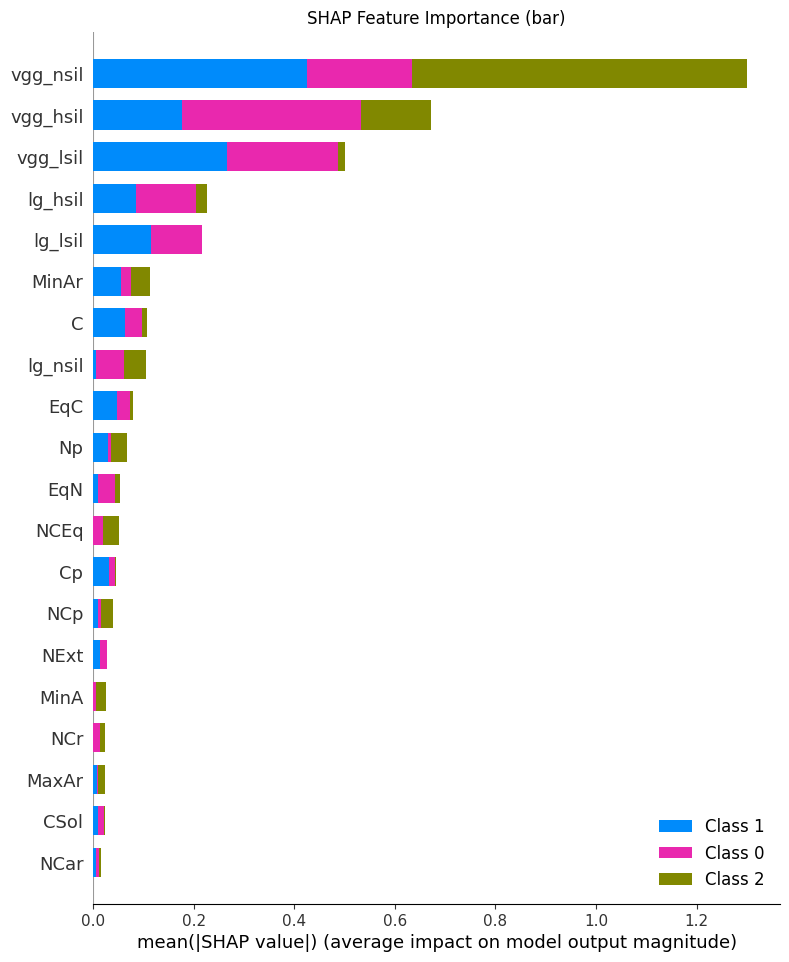

<Figure size 640x480 with 0 Axes>

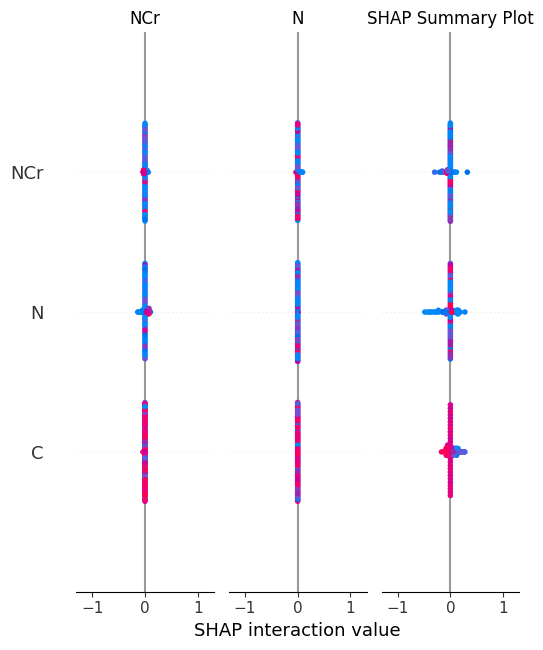

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

pipe = model_class["model"]  # Twój ImbPipeline z SVC
bg = shap.sample(X_train, 100, random_state=42)  # tło (możesz dać 200–500)

f = lambda X: pipe.decision_function(X)  # dla SVC lepsze niż predict_proba

explainer = shap.KernelExplainer(f, bg)
X_test_sample = shap.sample(X_test, 300, random_state=42)

shap_values = explainer.shap_values(X_test_sample)  # tu będzie macierz (nie lista)
feature_names = list(X_test.columns) if hasattr(X_test, "columns") else None

# Wykresy:
plt.figure(); shap.summary_plot(shap_values, X_test_sample, plot_type="bar",
                                feature_names=feature_names, show=False); plt.tight_layout(); plt.title("SHAP Feature Importance")
plt.figure(); shap.summary_plot(shap_values, X_test_sample,
                                feature_names=feature_names, show=False); plt.tight_layout(); plt.title("SHAP Summary Plot")


In [25]:
import os
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, precision_score, recall_score, f1_score, classification_report
from segmentation.modelsUnet import preprocess_image

y_true = []
y_pred = []
label_encoder = model_class["label_encoder"]
pipe = model_class["model"]
folder = r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\TEST'

model = UNet4Levels(in_channels=3, out_channels=2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\unet4_cell_nucleus_4_50_1310.pth"))
model.to(device)

def predict_fused(pipe, label_encoder, image_path):
    pil_image, input_tensor = preprocess_image(image_path)
    predicted_masks = predict_masks(model, input_tensor, device, threshold_nuclei=0.3, threshold_cell=0.7)
    cell_mask = predicted_masks[0]
    nucleus_mask = predicted_masks[1]
    features = extract_features(nucleus_mask, cell_mask)

    feature_names = ['N', 'C', 'NCr', 'Np', 'Cp', 'NCp', 'MinA', 'MinAr', 'MaxA', 'MaxAr',
                 'Nar', 'Car', 'NCar', 'NExt', 'CExt', 'NCExt', 'NSol', 'CSol', 'NCs',
                 'EqN', 'EqC', 'NCEq', 'OrN', 'OrC', 'NCOr']
    X_new = pd.DataFrame([[features[feat] for feat in feature_names]], columns=feature_names)

    probs1 = predict_gbm_probs(lightgbm_model, label_encoder, features)
    X_new["lg_hsil"] = probs1[0]
    X_new["lg_lsil"] = probs1[1]
    X_new["lg_nsil"] = probs1[2]

    probs2 = predict_vgg_probs(vgg_clf, image_path)
    X_new["vgg_hsil"] = probs2[0]
    X_new["vgg_lsil"] = probs2[1]
    X_new["vgg_nsil"] = probs2[2]

    

    y_pred_encoded = pipe.predict(X_new)
    predicted_class = label_encoder.inverse_transform(y_pred_encoded)[0]

    return predicted_class

for subfolder in os.listdir(folder):
    true_class = os.path.basename(subfolder)
    for filename in os.listdir(os.path.join(folder, subfolder)):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
            image_path = os.path.join(folder, subfolder, filename)
            predicted_class = predict_fused(pipe, label_encoder, image_path)
            y_true.append(true_class)
            y_pred.append(predicted_class)


acc = accuracy_score(y_true, y_pred)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
y_true, y_pred, labels=label_encoder.classes_, average="macro", zero_division=0
    )
prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=label_encoder.classes_, average="weighted", zero_division=0
    )

print("\n=== METRYKI (global) ===")
print(f"Accuracy:            {acc:.4f}")
print(f"Precision (macro):   {prec_macro:.4f}")
print(f"Recall    (macro):   {rec_macro:.4f}")
print(f"F1        (macro):   {f1_macro:.4f}")
print(f"Precision (weighted):{prec_weighted:.4f}")
print(f"Recall    (weighted):{rec_weighted:.4f}")
print(f"F1        (weighted):{f1_weighted:.4f}")

print("\n=== RAPORT (per klasa) ===")
print(classification_report(y_true, y_pred, labels=label_encoder.classes_, digits=4))

cm = confusion_matrix(y_true, y_pred, labels=label_encoder.classes_, normalize='true')
cm_df = pd.DataFrame(
        cm,
        index=[f"true_{l}" for l in label_encoder.classes_],
        columns=[f"pred_{l}" for l in label_encoder.classes_],
    )
print("\n=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===")
print(cm_df)



fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.set_title("Confusion Matrix (HSIL/LSIL/NSIL, normalized)")
tick_marks = np.arange(len(label_encoder.classes_))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(label_encoder.classes_)
ax.set_yticklabels(label_encoder.classes_)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", color="black")

ax.set_ylabel("True class")
ax.set_xlabel("Predicted class")
fig.tight_layout()
plt.close()


=== METRYKI (global) ===
Accuracy:            0.9310
Precision (macro):   0.9333
Recall    (macro):   0.9333
F1        (macro):   0.9333
Precision (weighted):0.9310
Recall    (weighted):0.9310
F1        (weighted):0.9310

=== RAPORT (per klasa) ===
              precision    recall  f1-score   support

        HSIL     0.9000    0.9000    0.9000        20
        LSIL     0.9000    0.9000    0.9000        20
        NSIL     1.0000    1.0000    1.0000        18

    accuracy                         0.9310        58
   macro avg     0.9333    0.9333    0.9333        58
weighted avg     0.9310    0.9310    0.9310        58


=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===
           pred_HSIL  pred_LSIL  pred_NSIL
true_HSIL        0.9        0.1        0.0
true_LSIL        0.1        0.9        0.0
true_NSIL        0.0        0.0        1.0
